# pyCSLDV showcase

**Continuous scanning laser Doppler vibrometry (CSLDV) in Python.**

In a CSLDV measurement the laser spot of the vibrometer sweeps *continuously* over the
vibrating surface instead of dwelling at discrete points. This notebook walks through the
complete workflow supported by `pyCSLDV`:

1. **Scan trajectory design** — Lissajous trajectory and galvo mirror drive signals,
2. **Virtual CSLDV experiment** — the velocity signal an LDV would measure,
3. **ODS reconstruction** — sideband demodulation in a 2D Chebyshev basis,
4. **Validation** — comparison with the exact shape using the modal assurance criterion (MAC).

The package can be installed with:

```console
pip install pyCSLDV
```

> **Origin:** pyCSLDV is an independent Python reimplementation of the *CSLDV Vibration
> Measurement & Simulation Suite* by Joshua Bartlett and Pablo Tarazaga (Texas A&M
> University), published under CC-BY-4.0 at
> [zenodo.org/records/21301126](https://zenodo.org/records/21301126)
> (DOI: [10.5281/zenodo.21301126](https://doi.org/10.5281/zenodo.21301126)). The original
> material has been modified; the differences are listed under *Origin and attribution* in
> the README.
>
> **Development note:** the initial Python implementation was written with Claude
> (Anthropic) and has not yet been reviewed by the authors of the original suite. The
> reconstruction is verified against a transcription of the original `ComputeODS.m` in
> `tests/test_matlab_reference.py`. The package is at an alpha stage.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pycsldv

pycsldv.__version__

'0.1.0'

## 1. Scan trajectory design

The two galvo mirrors are driven harmonically at frequencies $f_x$ and $f_y$, so the laser
spot traces a Lissajous pattern in normalized coordinates:

$$x(t) = \cos(2 \pi f_x t + \varphi_x), \qquad y(t) = \cos(2 \pi f_y t + \varphi_y).$$

The pattern closes after $1/\gcd(f_x, f_y)$ seconds; measuring for an integer number of
closure periods gives uniform surface coverage.

Lissajous closure period: 5.0 s


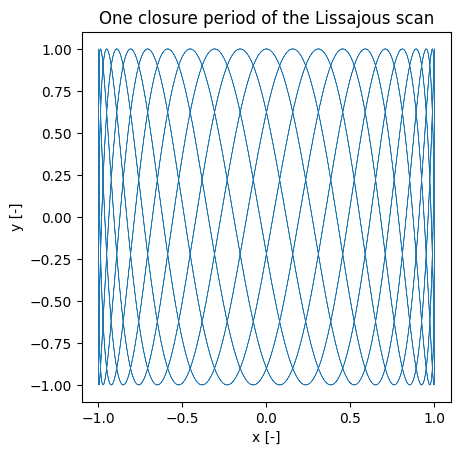

In [2]:
fs = 25000.0        # sampling frequency [Hz]
fx, fy = 1.4, 8.0   # scan frequencies [Hz]

T_scan = pycsldv.scan_period(fx, fy)
print(f'Lissajous closure period: {T_scan} s')

t, x, y = pycsldv.lissajous(fx, fy, n_samples=int(T_scan * fs), fs=fs)
ax = pycsldv.plot_trajectory(x, y)
ax.set_title('One closure period of the Lissajous scan');

In an experiment the normalized trajectory is mapped to mirror drive voltages with a
linear mirror characteristic:

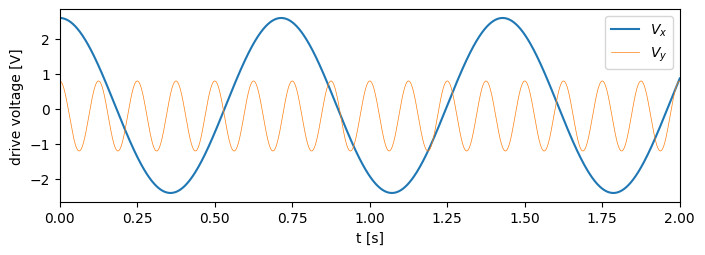

In [3]:
vx, vy = pycsldv.drive_signals(x, y, scale=(2.5, 1.0), offset=(0.1, -0.2))

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t, vx, label='$V_x$')
ax.plot(t, vy, label='$V_y$', linewidth=0.5)
ax.set(xlabel='t [s]', ylabel='drive voltage [V]', xlim=(0, 2))
ax.legend();

## 2. Virtual CSLDV experiment

For a harmonic response at frequency $f_z$ with an operating deflection shape (ODS)
expressed as a 2D Chebyshev series $\sum_{n,m} C_{nm}\, T_n(x)\, T_m(y)$, the measured
velocity is

$$v(t) = \mathrm{Re}\Big\{ \sum_{n,m} C_{nm}\, T_n(x(t))\, T_m(y(t))\, e^{i 2 \pi f_z t} \Big\}.$$

Here we simulate a 10 s measurement of a simply supported plate mode with 5 % additive
noise:

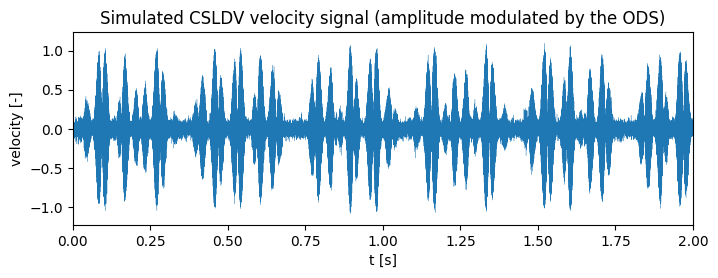

In [4]:
fz = 2000.0                    # response frequency [Hz]
duration = 10.0                # measurement duration [s]
n_samples = int(duration * fs)

shape = pycsldv.plate_mode(3, 2)
rng = np.random.default_rng(0)
t, x, y = pycsldv.lissajous(fx, fy, n_samples, fs)
velocity = pycsldv.simulate_response(shape, fz, x, y, fs, noise_std=0.05, rng=rng)

fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(t, velocity, linewidth=0.2)
ax.set(xlabel='t [s]', ylabel='velocity [-]', xlim=(0, 2),
       title='Simulated CSLDV velocity signal (amplitude modulated by the ODS)');

Because $T_n(\cos\theta) = \cos(n\theta)$, each Chebyshev coefficient appears as a set of
**sidebands** at $f_z \pm n f_x \pm m f_y$ around the response frequency — the deflection
shape is encoded in the spectrum of the single-point measurement:

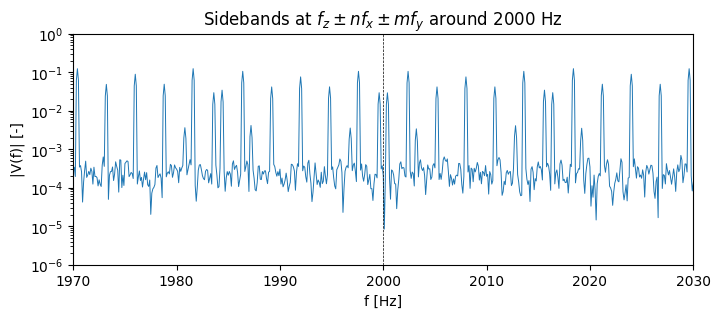

In [5]:
from scipy.signal.windows import hann

w = hann(n_samples, sym=False)
freq = np.fft.rfftfreq(n_samples, 1 / fs)
spectrum = 2 * np.abs(np.fft.rfft(w * velocity)) / w.sum()

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(freq, spectrum, linewidth=0.7)
ax.set(xlabel='f [Hz]', ylabel='|V(f)| [-]', xlim=(fz - 30, fz + 30), ylim=(1e-6, 1),
       title=f'Sidebands at $f_z \\pm n f_x \\pm m f_y$ around {fz:.0f} Hz')
ax.axvline(fz, color='k', linewidth=0.5, linestyle='--');

## 3. ODS reconstruction by sideband demodulation

`demodulate_ods` projects the velocity signal onto the sideband frequencies and returns the
complex Chebyshev coefficient matrix. The mirror phases (inertial lag) are estimated from
the mirror signals themselves, and `align_phase` removes the arbitrary global response
phase:

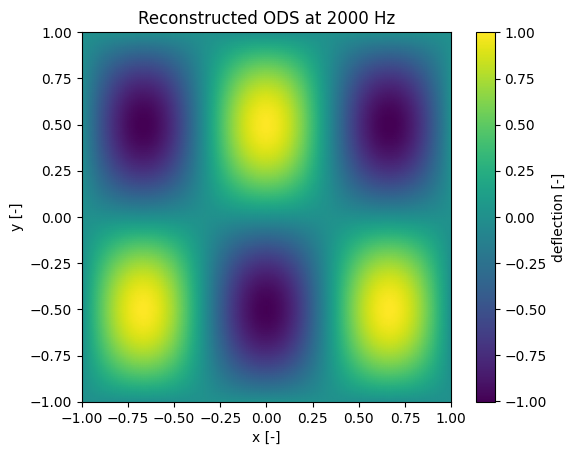

In [6]:
C = pycsldv.demodulate_ods_2d(velocity, fs, fx, fy, fz, order=8, phi_x=0.0, phi_y=0.0)

# The old implementation is still supported:
# C = pycsldv.demodulate_ods(velocity, x, y, fs, fx, fy, fz, order=8)
# C = pycsldv.align_phase(C)

ax = pycsldv.plot_ods(C)
ax.set_title(f'Reconstructed ODS at {fz:.0f} Hz');

## 4. Validation against the exact shape

The reconstruction is evaluated on a grid and compared with the exact deflection shape
using the MAC:

MAC(exact, reconstructed) = 1.0000


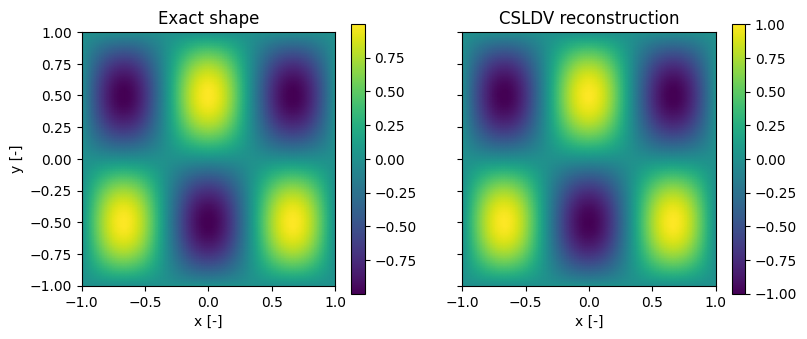

In [7]:
X, Y, Z = pycsldv.evaluate_ods(C, resolution=100)
exact = shape(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for ax, z, title in zip(axes, [exact, Z.real], ['Exact shape', 'CSLDV reconstruction']):
    mesh = ax.pcolormesh(X, Y, z, cmap='viridis', shading='gouraud')
    fig.colorbar(mesh, ax=ax)
    ax.set(title=title, xlabel='x [-]', aspect='equal')
axes[0].set_ylabel('y [-]')

print(f'MAC(exact, reconstructed) = {pycsldv.mac(exact, Z.real):.4f}')

The same virtual experiment repeated for several plate modes shows that the approach
generalizes across shapes of increasing spatial complexity:

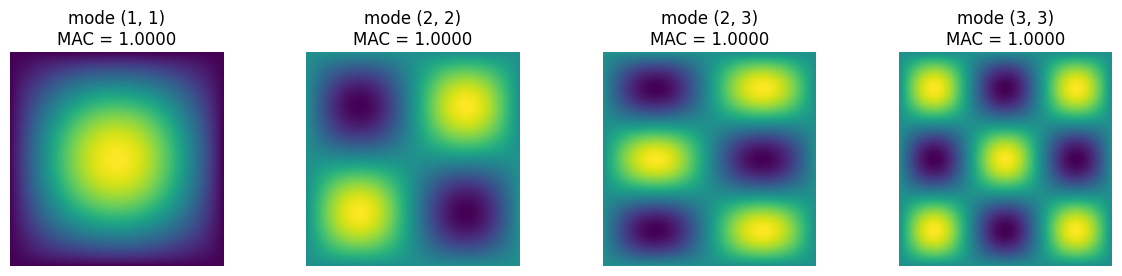

In [8]:
modes = [(1, 1), (2, 2), (2, 3), (3, 3)]

fig, axes = plt.subplots(1, len(modes), figsize=(3 * len(modes), 2.8))
for ax, (p, q) in zip(axes, modes):
    shape_pq = pycsldv.plate_mode(p, q)
    v_pq = pycsldv.simulate_response(shape_pq, fz, x, y, fs, noise_std=0.05, rng=rng)
    C_pq = pycsldv.align_phase(
        pycsldv.demodulate_ods(v_pq, x, y, fs, fx, fy, fz, order=8))
    Xg, Yg, Zg = pycsldv.evaluate_ods(C_pq, resolution=100)
    mac_pq = pycsldv.mac(shape_pq(Xg, Yg), Zg.real)
    ax.pcolormesh(Xg, Yg, Zg.real, cmap='viridis', shading='gouraud')
    ax.set(title=f'mode ({p}, {q})\nMAC = {mac_pq:.4f}', aspect='equal')
    ax.set_axis_off()
fig.tight_layout()

pycsldv has no problem with a signals containing multiple modes

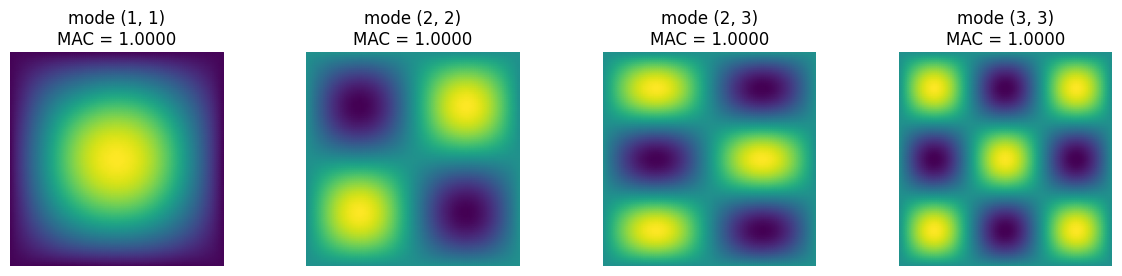

In [10]:
modes = [(1, 1), (2, 2), (2, 3), (3, 3)]

fig, axes = plt.subplots(1, len(modes), figsize=(3 * len(modes), 2.8))
velocity = np.zeros_like(x)
fn = []
for p, q in modes:
    shape_pq = pycsldv.plate_mode(p, q)
    fn_pq = pycsldv.plate_frequency(p, q)
    velocity += pycsldv.simulate_response(shape_pq, fn_pq, x, y, fs, noise_std=0.05, rng=rng)
    fn.append(fn_pq)

C = pycsldv.demodulate_ods_2d(velocity, fs, fx, fy, fn, order=8, phi_x=0.0, phi_y=0.0)

for ax, C_pq, (p,q) in zip(axes, C, modes):
    shape_pq = pycsldv.plate_mode(p, q)
    Xg, Yg, Zg = pycsldv.evaluate_ods(C_pq, resolution=100)
    mac_pq = pycsldv.mac(shape_pq(Xg, Yg), Zg.real)
    ax.pcolormesh(Xg, Yg, Zg.real, cmap='viridis', shading='gouraud')
    ax.set(title=f'mode ({p}, {q})\nMAC = {mac_pq:.4f}', aspect='equal')
    ax.set_axis_off()
fig.tight_layout()

## References

- J. Bartlett, P. Tarazaga: *Continuous Scanning Laser Doppler Vibrometry (CSLDV)
  Vibration Measurement & Simulation Suite*, Zenodo, 2026, DOI:
  [10.5281/zenodo.21301126](https://doi.org/10.5281/zenodo.21301126).
- A. B. Stanbridge, D. J. Ewins: *Modal testing using a scanning laser Doppler vibrometer*,
  Mechanical Systems and Signal Processing 13(2), 1999, 255–270.
- S. Rothberg et al.: *An international review of laser Doppler vibrometry: Making light
  work of vibration measurement*, Optics and Lasers in Engineering 99, 2017, 11–22.